In [1]:
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import sys
import json

from util.config_utils import load_yaml
from util.metrics import analyze_preds, load_preds

import warnings
warnings.filterwarnings('ignore')

In [2]:
val_20_paths = [
    ['1000_run', 'val_merciless'],
    ['2000_run', 'val_vain'],
    ['3000_run', 'val_big'],
    ['4000_run', 'val_silver'],
    ['5000_run', 'val_perfect'],
    ['6000_run', 'val_cyan'],
    ['7000_run', 'val_bland'],
    ['8000_run', 'val_drab']
]

test_20_paths = [
    ['1000_run', 'test_20_azure'],
    ['2000_run', 'test_20_rude'],
    ['3000_run', 'test_20_allegro'],
    ['4000_run', 'test_20_greasy'],
    ['5000_run', 'test_20_tough'],
    ['6000_run', 'test_20_tart'],
    ['7000_run', 'test_20_tangy'],
    ['8000_run', 'test_20_merciless']
]

test_10_paths = [
    ['1000_run', 'test_10_glide'],
    ['2000_run', 'test_10_penny'],
    ['3000_run', 'test_10_cathode'],
    ['4000_run', 'test_10_epigram'],
    ['5000_run', 'test_10_yard'],
    ['6000_run', 'test_10_transmission'],
    ['7000_run', 'test_10_user'],
    ['8000_run', 'test_10_boondoggle']
]

test_5_paths = [
    ['1000_run', 'test_5_boondoggle'],
    ['2000_run', 'test_5_boulevard'],
    ['3000_run', 'test_5_igloo'],
    ['4000_run', 'test_5_line'],
    ['5000_run', 'test_5_event'],
    ['6000_run', 'test_5_aqueduct'],
    ['7000_run', 'test_5_statement'],
    ['8000_run', 'test_5_purlin']
]

test_2_paths = [
    ['1000_run', 'test_2_skin'],
    ['2000_run', 'test_2_arena'],
    ['3000_run', 'test_2_pitch'],
    ['4000_run', 'test_2_concierge'],
    ['5000_run', 'test_2_plasma'],
    ['6000_run', 'test_2_limousine'],
    ['7000_run', 'test_2_inventory'],
    ['8000_run', 'test_2_decorator']
]

test_1_paths = [
    ['1000_run', 'test_1_bean'],
    ['2000_run', 'test_1_pinscher'],
    ['3000_run', 'test_1_translation'],
    ['4000_run', 'test_1_turret'],
    ['5000_run', 'test_1_octave'],
    ['6000_run', 'test_1_alert'],
    ['7000_run', 'test_1_bow'],
    ['8000_run', 'test_1_valley']
]


In [5]:
def plot_metrics(paths):
    neural_metrics = []
    rules_metrics = []
    joint_metrics = []
    
    # Define font sizes
    TITLE_SIZE = 14
    AXIS_LABEL_SIZE = 12
    TICK_SIZE = 10
    LEGEND_SIZE = 10

    for run_name, test_run_name in paths:
        cfg = load_yaml(os.path.join('runs/', run_name, 'test_runs', test_run_name, 'config.yaml'))
        neural_metrics.append(analyze_preds(cfg, run_name, test_run_name, preds='neural', do_print=True))
        rules_metrics.append(analyze_preds(cfg, run_name, test_run_name, preds='rules', do_print=True))
        joint_metrics.append(analyze_preds(cfg, run_name, test_run_name, preds='joint', do_print=True))


    # Assuming analyze_preds returns a dictionary of metrics
    metric_names = neural_metrics[0].keys()

    # Plotting
    num_metrics = len(metric_names)
    fig, axes = plt.subplots(num_metrics, 1, figsize=(12, 4 * num_metrics), sharex=True)

    for i, metric in enumerate(metric_names):
        neural_values = [metrics[metric] for metrics in neural_metrics]
        rules_values = [metrics[metric] for metrics in rules_metrics]
        joint_values = [metrics[metric] for metrics in joint_metrics]
        
        axes[i].plot(range(len(paths)), neural_values, label='Neural', marker='o')
        axes[i].plot(range(len(paths)), rules_values, label='Rules', marker='o')
        axes[i].plot(range(len(paths)), joint_values, label='Joint', marker='o')
        
        axes[i].set_title(f'{metric} over Different Runs', fontsize=TITLE_SIZE)
        axes[i].set_ylabel(metric, fontsize=AXIS_LABEL_SIZE)
        axes[i].legend(fontsize=LEGEND_SIZE)
        axes[i].tick_params(axis='both', labelsize=TICK_SIZE)
    
    axes[-1].set_xlabel('Run Index', fontsize=AXIS_LABEL_SIZE)
    axes[-1].set_xticks(ticks=range(len(paths)))
    axes[-1].set_xticklabels([run[0] for run in paths], rotation=45, fontsize=TICK_SIZE)
    
    plt.tight_layout()
    plt.show()

def compare_all_paths(paths_dict):
    """
    Plot metrics for different path sets on the same graph for comparison.
    
    Args:
        paths_dict: Dictionary mapping path set names to path lists
                    e.g., {'test_5': test_5_paths, 'test_10': test_10_paths}
    """
    # Define font sizes
    TITLE_SIZE = 16
    AXIS_LABEL_SIZE = 14
    TICK_SIZE = 12
    LEGEND_SIZE = 12
    
    # Get all metrics from the first path set to determine what to plot
    sample_path_set = list(paths_dict.values())[0]
    sample_run_name, sample_test_run_name = sample_path_set[0]
    sample_cfg = load_yaml(os.path.join('runs/', sample_run_name, 'test_runs', sample_test_run_name, 'config.yaml'))
    sample_metrics = analyze_preds(sample_cfg, sample_run_name, sample_test_run_name, preds='neural', do_print=False)
    metric_names = sample_metrics.keys()
    
    # Get a reference path set for neural and rules models
    reference_paths = list(paths_dict.values())[0]
    
    # Create a figure with subplots arranged in two columns
    num_metrics = len(metric_names)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    #fig.suptitle(f'Metrics Comparison Across Different Test Sets', fontsize=16)
    
    # Flatten axes array for easier indexing
    axes = axes.flatten() if num_metrics > 1 else [axes]
    
    weights = {
        'test_1': 1, 
        'test_5': 5, 
        'test_20': 20,
    }
    joint_markers = {
        'test_1': 'D',  # diamond
        'test_5': 'v',  # pentagon
        'test_20': '^', # triangle
    }
    
    for i, metric in enumerate(metric_names):
        
        # Plot neural model
        x_values = [int(run_name.split('_')[0]) for run_name, _ in reference_paths]
        neural_values = []
        for run_name, test_run_name in reference_paths:
            cfg = load_yaml(os.path.join('runs/', run_name, 'test_runs', test_run_name, 'config.yaml'))
            metrics = analyze_preds(cfg, run_name, test_run_name, preds='neural', do_print=False)
            # Convert to percentage for appropriate metrics
            if metric != "Mean Entropy(lower is better)":
                neural_values.append(metrics[metric] * 100)
            else:
                neural_values.append(metrics[metric])
        axes[i].plot(x_values, neural_values, linestyle='--', marker='o', label="Neural")
        
        # Plot rules model
        rules_values = []
        for run_name, test_run_name in reference_paths:
            cfg = load_yaml(os.path.join('runs/', run_name, 'test_runs', test_run_name, 'config.yaml'))
            metrics = analyze_preds(cfg, run_name, test_run_name, preds='rules', do_print=False)
            # Convert to percentage for appropriate metrics
            if metric != "Mean Entropy(lower is better)":
                rules_values.append(metrics[metric] * 100)
            else:
                rules_values.append(metrics[metric])
        axes[i].plot(x_values, rules_values, linestyle='--', marker='s', label="Rules")
        
        axes[i].set_title(f'{metric}', fontsize=TITLE_SIZE)
        #axes[i].set_ylabel(metric)
        axes[i].set_xlabel('# of examples', fontsize=AXIS_LABEL_SIZE)
        axes[i].grid(True, linestyle='--', alpha=0.7)
        axes[i].tick_params(axis='both', labelsize=TICK_SIZE)
        
        # Plot joint model for each path set first
        for path_name, paths in reversed(paths_dict.items()):
            x_values = [int(run_name.split('_')[0]) for run_name, _ in paths]
            joint_values = []
            
            for run_name, test_run_name in paths:
                cfg = load_yaml(os.path.join('runs/', run_name, 'test_runs', test_run_name, 'config.yaml'))
                metrics = analyze_preds(cfg, run_name, test_run_name, preds='joint', do_print=False)
                # Convert to percentage for appropriate metrics
                if metric != "Mean Entropy(lower is better)":
                    joint_values.append(metrics[metric] * 100)
                else:
                    joint_values.append(metrics[metric])
            
            axes[i].plot(x_values, joint_values, linestyle='-', marker=joint_markers[path_name], 
                         linewidth=1, label=f"Joint@{weights[path_name]}")
        
        # Only show legend for the first subplot to avoid clutter
        if i < 4 :
            axes[i].legend(['Neural only', 'Rules only', 'LeaPR@20', 'LeaPR@5', 'LeaPR@1'], fontsize=LEGEND_SIZE)
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()


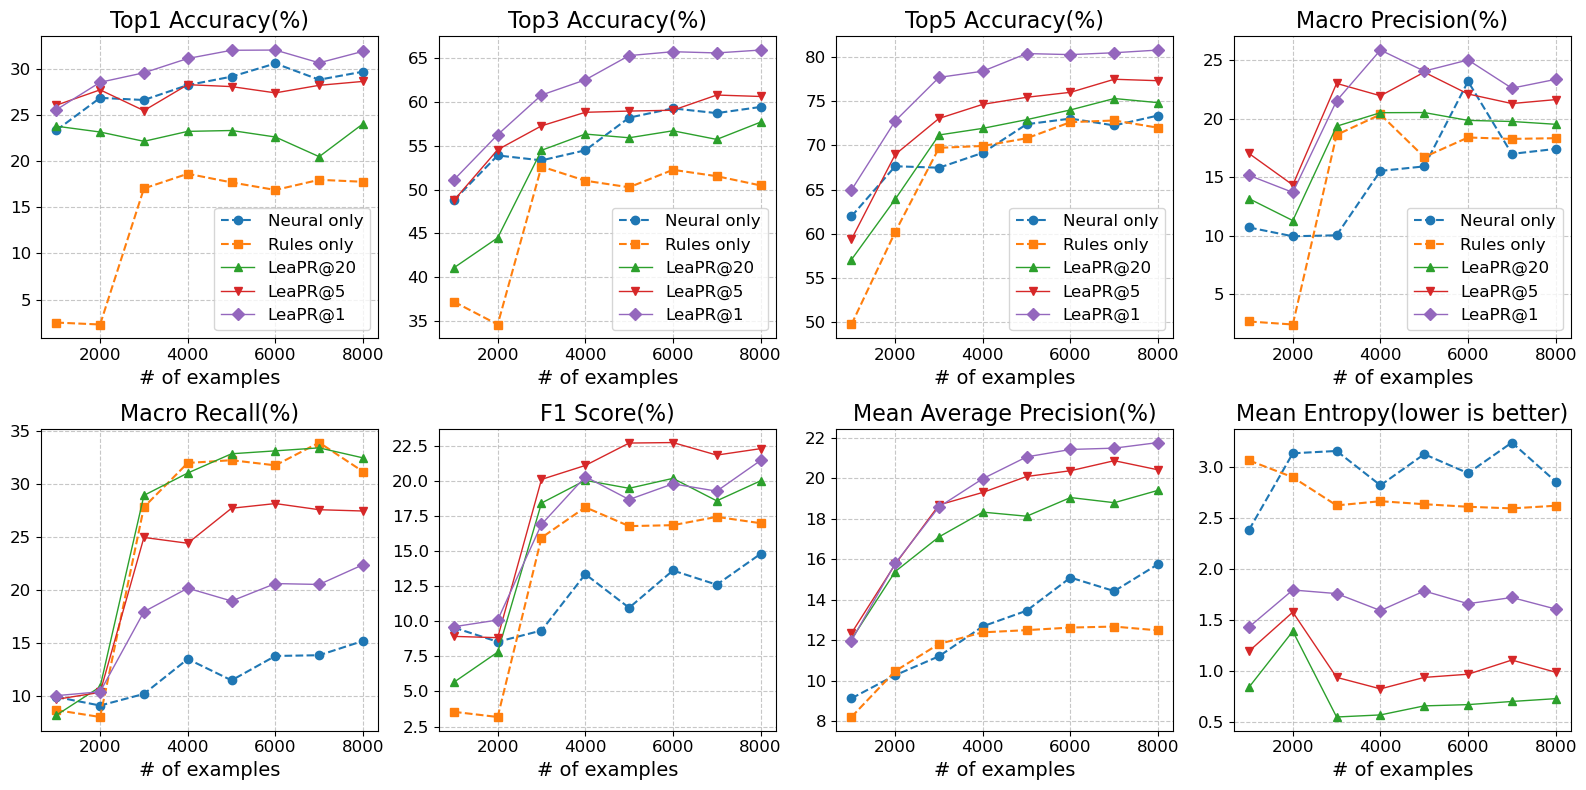

In [6]:
paths_dict = {
    'test_1': test_1_paths,
    #'test_2': test_2_paths,
    'test_5': test_5_paths,
    #'test_10': test_10_paths,
    'test_20': test_20_paths
}
compare_all_paths(paths_dict)

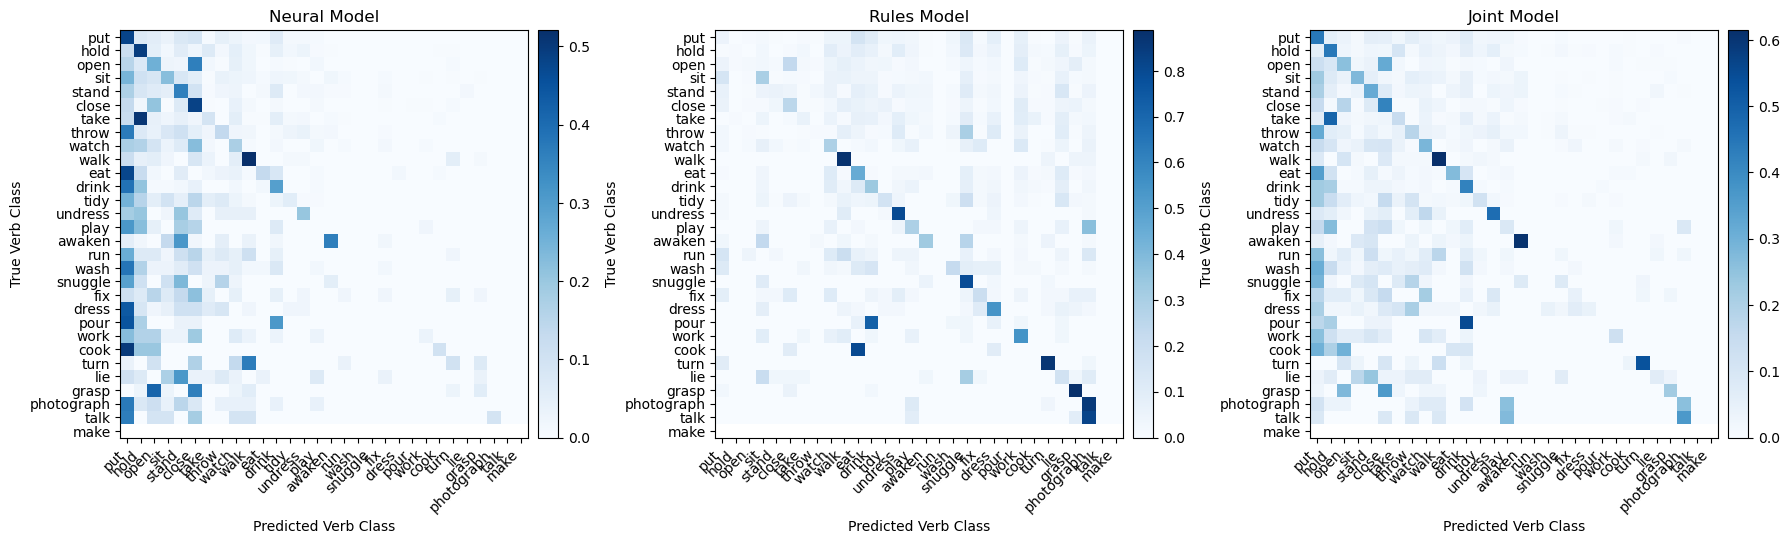

Neural Model Accuracy: 0.2971
Rules Model Accuracy: 0.1778
Joint Model Accuracy: 0.3192


In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from mpl_toolkits.axes_grid1 import make_axes_locatable


# Load predictions and labels from the 8000_run
run_name = '8000_run'
test_run_name = 'test_20_valley'  # Assuming we're using test_20 for evaluation
cfg = load_yaml(os.path.join('runs/', run_name, 'test_runs', test_run_name, 'config.yaml'))

# Load the predictions for each model type
true_labels = load_preds(cfg, run_name, test_run_name, preds='neural')[:, 1]
neural_preds = load_preds(cfg, run_name, test_run_name, preds='neural')[:, 0]
rules_preds = load_preds(cfg, run_name, test_run_name, preds='rules')[:, 0]
joint_preds = load_preds(cfg, run_name, test_run_name, preds='joint')[:, 0]

# Convert predictions and labels to class indices
y_true = np.argmax(true_labels, axis=1)
y_neural = np.argmax(neural_preds, axis=1)
y_rules = np.argmax(rules_preds, axis=1)
y_joint = np.argmax(joint_preds, axis=1)

# Get unique classes
num_classes = true_labels.shape[1]
classes = np.arange(num_classes)

# Load verb classes and their priors
with open('runs/8000_run/verb_priors.json', 'r') as f:
    verb_data = json.load(f)
    verb_classes = verb_data['verbs']
    verb_priors = verb_data['priors']

# Sort classes by frequency (priors)
sorted_indices = np.argsort(verb_priors)[::-1]  # Sort in descending order
sorted_classes = np.array(classes)[sorted_indices]
sorted_verb_classes = [verb_classes[i] for i in sorted_indices]

# Reorder confusion matrices according to frequency
cm_neural = confusion_matrix(y_true, y_neural, labels=sorted_classes)
cm_rules = confusion_matrix(y_true, y_rules, labels=sorted_classes)
cm_joint = confusion_matrix(y_true, y_joint, labels=sorted_classes)

# Normalize confusion matrices
cm_neural_norm = cm_neural.astype('float') / cm_neural.sum(axis=1)[:, np.newaxis]
cm_rules_norm = cm_rules.astype('float') / cm_rules.sum(axis=1)[:, np.newaxis]
cm_joint_norm = cm_joint.astype('float') / cm_joint.sum(axis=1)[:, np.newaxis]

# Create a figure with 3 subplots for the confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['Neural Model', 'Rules Model', 'Joint Model']
cms = [cm_neural_norm, cm_rules_norm, cm_joint_norm]

for i, (ax, cm, title) in enumerate(zip(axes, cms, titles)):
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)
    
    # Add colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    plt.colorbar(im, cax=cax)
    
    # Set tick marks and labels
    tick_marks = np.arange(len(sorted_classes))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    
    # Use sorted verb names
    ax.set_xticklabels(sorted_verb_classes, rotation=45, ha='right')
    ax.set_yticklabels(sorted_verb_classes)
    
    # Add labels
    ax.set_ylabel('True Verb Class')
    ax.set_xlabel('Predicted Verb Class')

plt.tight_layout()
plt.show()

# Print accuracy scores for reference
print(f"Neural Model Accuracy: {accuracy_score(y_true, y_neural):.4f}")
print(f"Rules Model Accuracy: {accuracy_score(y_true, y_rules):.4f}")
print(f"Joint Model Accuracy: {accuracy_score(y_true, y_joint):.4f}")


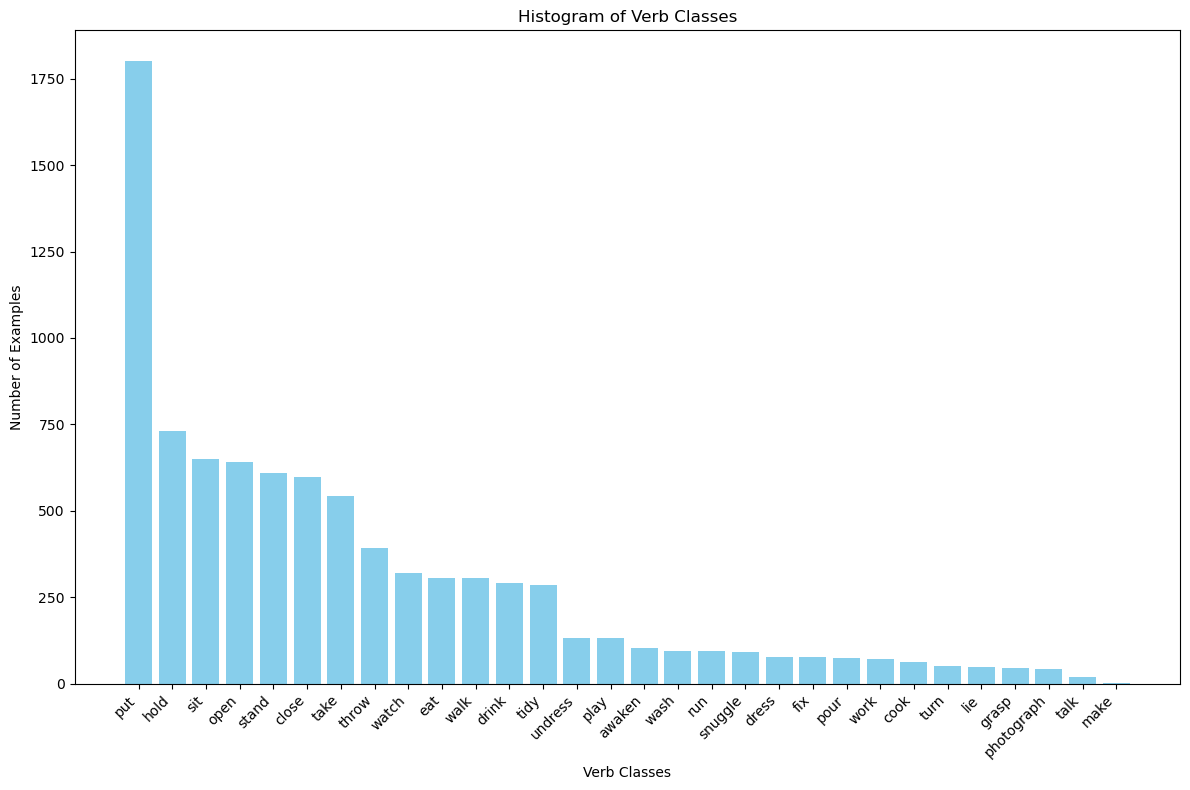

In [5]:
# Load the verb priors
with open('runs/full_vain-application/verb_priors.json', 'r') as f:
    verb_priors = json.load(f)

verbs = verb_priors['verbs']
priors = verb_priors['priors']

# Assuming the total number of examples in the data is the sum of priors
total_examples = 8693

# Calculate the number of examples for each verb class
verb_counts = [prior * total_examples for prior in priors]

# Sort the verbs and counts from most to least
sorted_indices = sorted(range(len(verb_counts)), key=lambda i: verb_counts[i], reverse=True)
sorted_verbs = [verbs[i] for i in sorted_indices]
sorted_counts = [verb_counts[i] for i in sorted_indices]

# Plotting the histogram
plt.figure(figsize=(12, 8))
plt.bar(sorted_verbs, sorted_counts, color='skyblue')
plt.xlabel('Verb Classes')
plt.ylabel('Number of Examples')
plt.title('Histogram of Verb Classes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


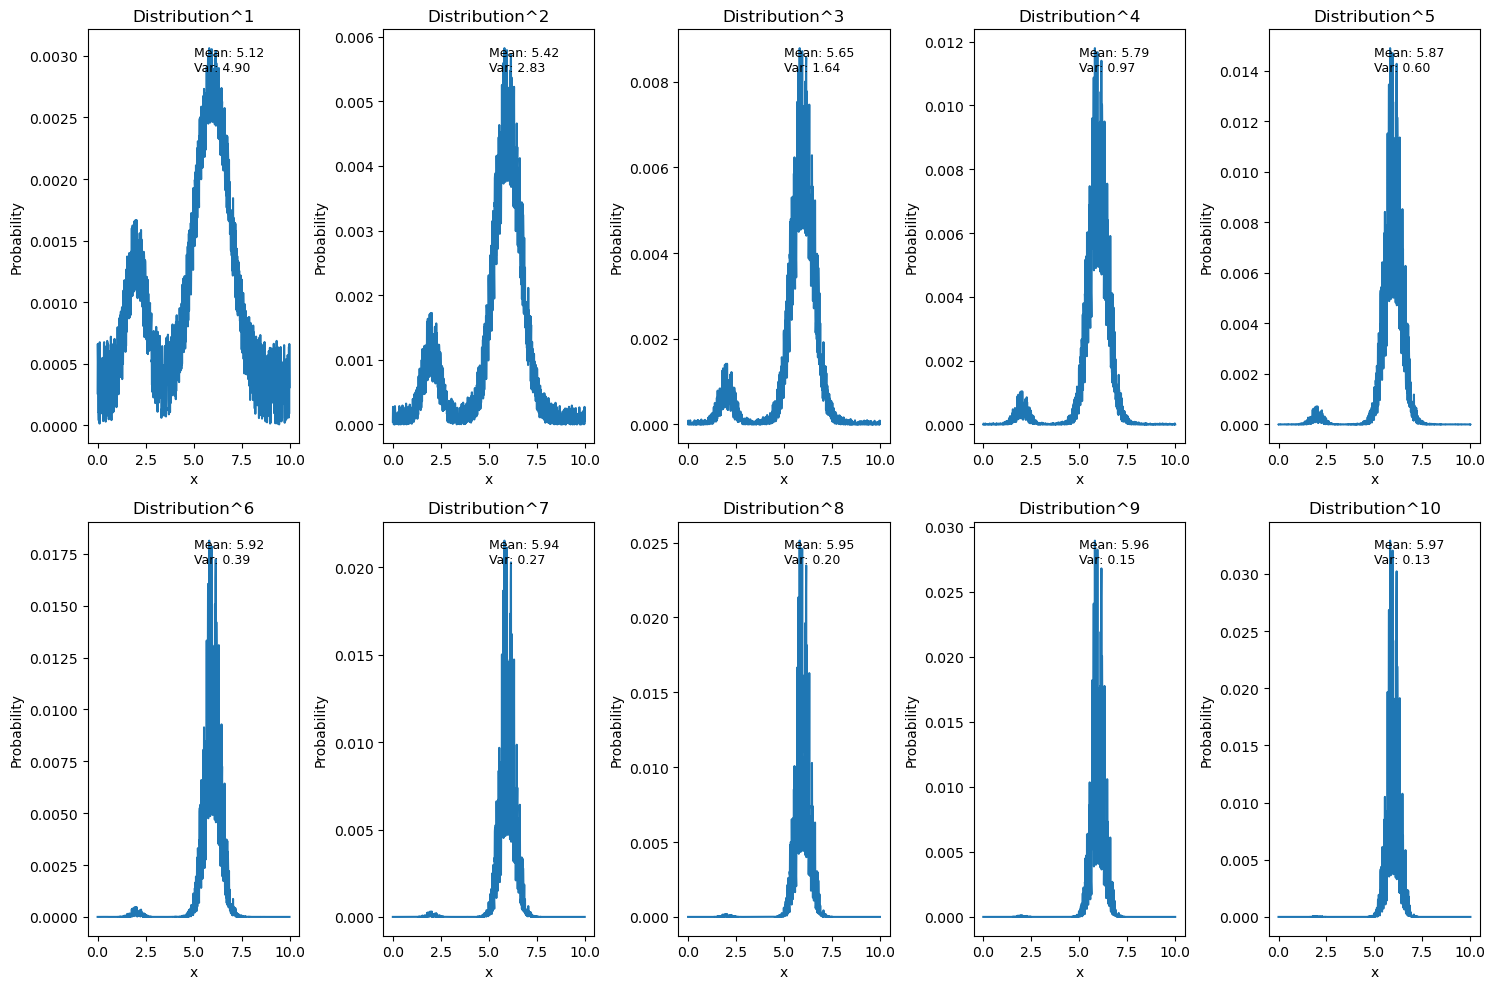

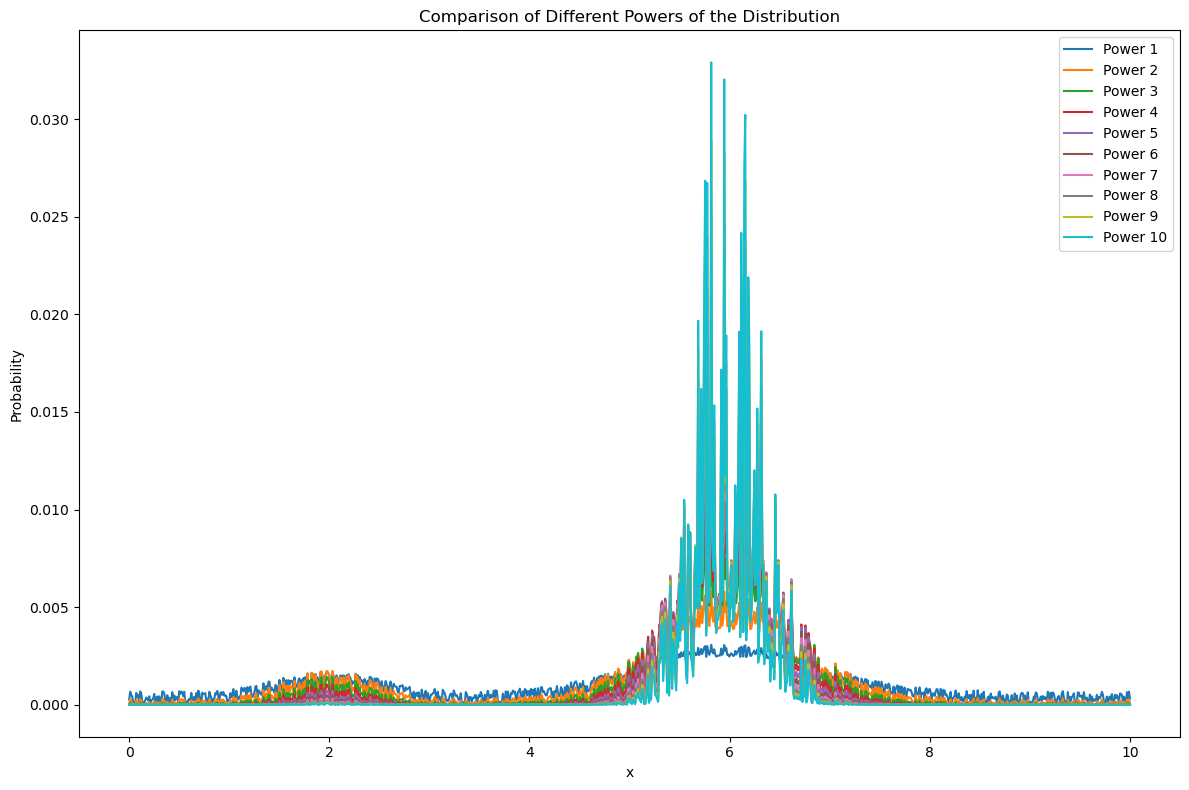

In [24]:
# Create a random distribution
import numpy as np
import matplotlib.pyplot as plt

# Generate a random distribution (using a mixture of normal distributions)
np.random.seed(42)  # For reproducibility
x = np.linspace(0, 10, 1000)
distribution = (
    0.3 * np.exp(-(x - 2)**2 / 0.5) + 
    0.7 * np.exp(-(x - 6)**2 / 1.5) +
    0.2 * np.random.random(1000)
)
# Normalize the distribution
distribution = distribution / np.sum(distribution)

# Create a figure to plot the original distribution and its powers
plt.figure(figsize=(15, 10))

# Plot powers of the distribution from 1 to 10
powers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
for i, power in enumerate(powers):
    # Calculate the power of the distribution
    powered_dist = distribution ** power
    # Normalize again
    powered_dist = powered_dist / np.sum(powered_dist)
    
    # Create subplot
    plt.subplot(2, 5, i+1)
    plt.plot(x, powered_dist)
    plt.title(f'Distribution^{power}')
    plt.xlabel('x')
    plt.ylabel('Probability')
    
    # Add some statistics
    mean = np.sum(x * powered_dist)
    variance = np.sum((x - mean)**2 * powered_dist)
    plt.text(0.5, 0.9, f'Mean: {mean:.2f}\nVar: {variance:.2f}', 
             transform=plt.gca().transAxes, fontsize=9)

plt.tight_layout()
plt.show()

# Also plot all distributions in one figure to compare
plt.figure(figsize=(12, 8))
for power in powers:
    powered_dist = distribution ** power
    powered_dist = powered_dist / np.sum(powered_dist)
    plt.plot(x, powered_dist, label=f'Power {power}')

plt.title('Comparison of Different Powers of the Distribution')
plt.xlabel('x')
plt.ylabel('Probability')
plt.legend()
plt.tight_layout()
plt.show()
